# 04 · Clima

Busca temperatura e chuva na NASA POWER, junta com os focos e compara um modelo só com histórico contra um com histórico + clima.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import shap

import sys; sys.path.append("..")
from src import climate_loader, features, models
from src.config import FIRST_YEAR, LAST_YEAR

In [2]:
clima = climate_loader.load_climate(FIRST_YEAR, LAST_YEAR)
clima.head()

,bioma,mes,t2m,precipitacao
0,Amazônia,2015-01-01,26.31,5.96
1,Amazônia,2015-02-01,26.44,4.78
2,Amazônia,2015-03-01,26.06,7.02
3,Amazônia,2015-04-01,26.10,4.24
4,Amazônia,2015-05-01,26.34,4.74


## Clima ao longo do tempo

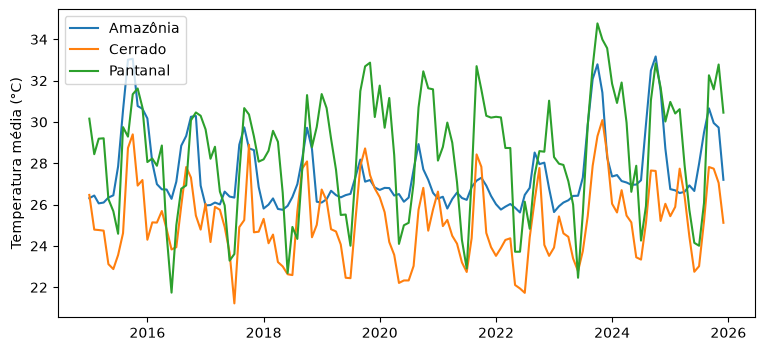

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for bioma, grupo in clima.groupby("bioma"):
    ax.plot(grupo["mes"], grupo["t2m"], label=bioma)
ax.set_ylabel("Temperatura média (°C)")
ax.legend()

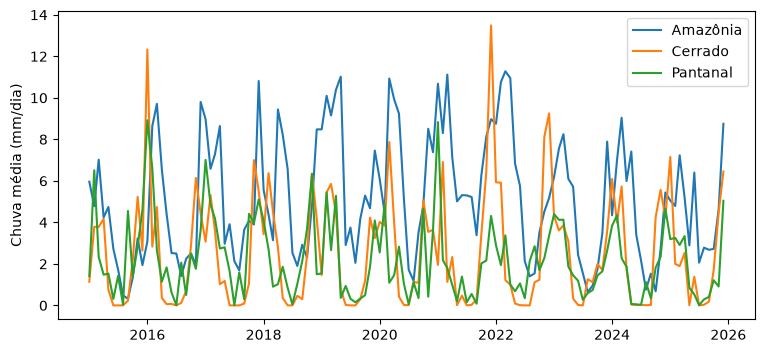

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for bioma, grupo in clima.groupby("bioma"):
    ax.plot(grupo["mes"], grupo["precipitacao"], label=bioma)
ax.set_ylabel("Chuva média (mm/dia)")
ax.legend()

## Juntando clima e focos

In [9]:
monthly = pd.read_csv("../data/processed/focos_mensais.csv", parse_dates=["mes"])
combinado = features.merge_climate(monthly, clima)
combinado.isna().sum()

bioma           0
mes             0
focos           0
t2m             0
precipitacao    0
dtype: int64

In [10]:
df = features.add_features(combinado)
df[["bioma", "mes", "t2m", "precipitacao", "focos"]].head()

,bioma,mes,t2m,precipitacao,focos
0,Amazônia,2016-01-01,30.17,3.08,4657
1,Amazônia,2016-02-01,28.03,8.64,1559
2,Amazônia,2016-03-01,26.99,9.71,2024
3,Amazônia,2016-04-01,26.74,6.55,1075
4,Amazônia,2016-05-01,26.73,4.40,895


## Modelo só com histórico vs histórico + clima

In [14]:
train, test = models.time_split(df, "2024-01-01")
train.shape, test.shape

((288, 13), (72, 13))

In [18]:
modelo_historico = models.train_lgbm(train, features=models.FEATURES_HISTORICO)
preds_historico = models.predict(modelo_historico, test, features=models.FEATURES_HISTORICO)
models.evaluate(test, preds_historico)

{'MAE': 2702.0515465712774}

In [19]:
modelo_clima = models.train_lgbm(train, features=models.FEATURES)
preds_clima = models.predict(modelo_clima, test, features=models.FEATURES)
models.evaluate(test, preds_clima)

{'MAE': 2479.7162471024635}

## O que pesa mais: histórico ou clima?

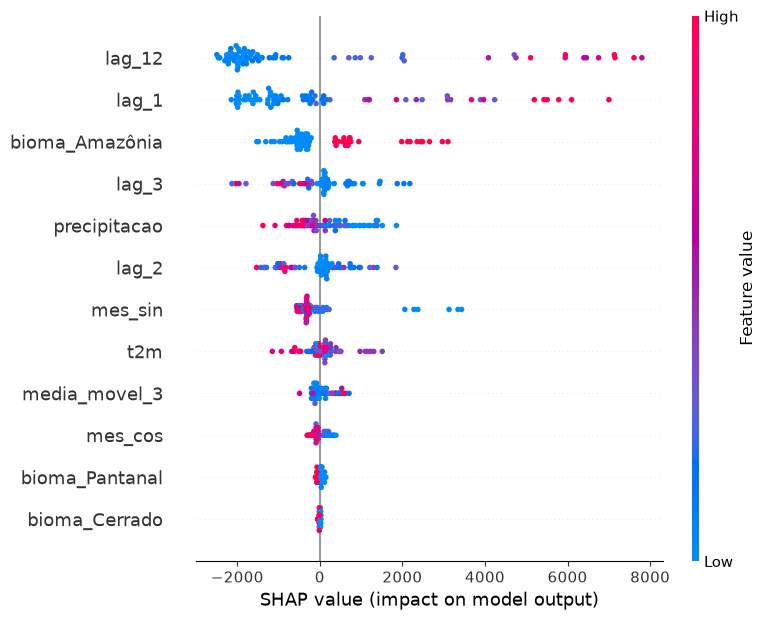

In [21]:
X_test = models.build_X(test, features=models.FEATURES, columns=modelo_clima.feature_name_)
explainer = shap.TreeExplainer(modelo_clima)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [26]:
import numpy as np

importancia_media = np.abs(shap_values).mean(axis=0)
por_variavel = pd.Series(importancia_media, index=X_test.columns).sort_values(ascending=False)

grupo_clima = por_variavel[["t2m", "precipitacao"]].sum()
grupo_historico = por_variavel.drop(["t2m", "precipitacao"]).sum()

print(f"Histórico: {grupo_historico:.1f}")
print(f"Clima: {grupo_clima:.1f}")
print(f"Participação do clima: {grupo_clima / (grupo_clima + grupo_historico):.1%}")

Histórico: 7207.3
Clima: 867.5
Participação do clima: 10.7%


## Conclusões desta etapa

- **O clima ajuda, mas é um efeito secundário:** incluir temperatura e chuva reduziu o MAE de 2.702 para 2.480 (queda de ~8%), uma melhora real, porém menor que o salto entre o baseline e o modelo com histórico (23%).
- **Resposta à pergunta do projeto:** segundo o SHAP, o histórico (lags e sazonalidade) responde por cerca de 89% da influência sobre as previsões, e o clima por cerca de 11%. O histórico pesa mais, mas o clima não é irrelevante.
- **A chuva pesa mais que a temperatura:** e na direção esperada, meses mais chuvosos reduzem a previsão de focos, o que é consistente com o conhecimento físico do fenômeno.
- **Por que o histórico já "carrega" o clima:** grande parte do padrão sazonal (seca em agosto–outubro) se repete todo ano, então os lags e a sazonalidade já capturam boa parte do efeito climático de forma indireta, mesmo sem ver a chuva diretamente.
- **Limitações:** o clima foi medido num único ponto por bioma, não no local de cada foco; e a chuva usada é uma média diária do mês, não o total. Uma extensão futura seria usar chuva de vários pontos por bioma, ou por Estado.